1.2.1


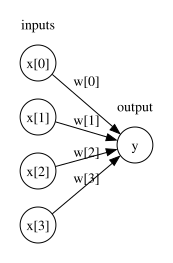

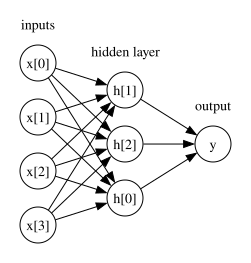

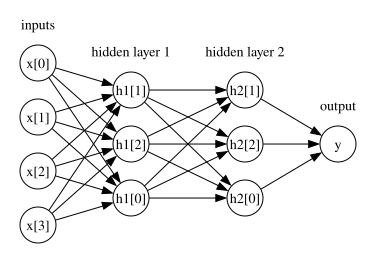

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import pandas as pd

print(sklearn.__version__)

#data_url = "http://lib.stat.cmu.edu/datasets/boston"
#raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
#data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
#target = raw_df.values[1::2, 2]

import mglearn

display(mglearn.plots.plot_logistic_regression_graph())


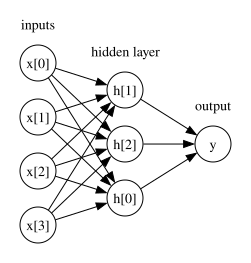

In [2]:
display(mglearn.plots.plot_single_hidden_layer_graph())

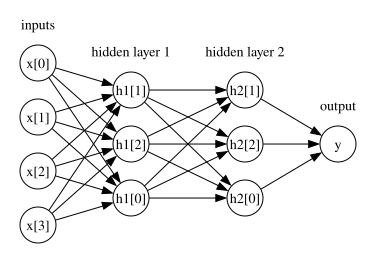

In [3]:
display(mglearn.plots.plot_two_hidden_layer_graph())

In [54]:
#Exemple simple d'implémentation complète:
# Comme précédemment, on charge les données "IRIS"
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
iris = load_iris()

x_trn, x_tst, y_trn, y_tst = train_test_split(iris['data'], iris['target'], stratify=iris['target'], random_state=0)
print("Size of the training set :", x_trn.shape)
print("Size of the testing set:", x_tst.shape)

y_trn[y_trn==2]=0
y_tst[y_tst==2]=0
y_trn = y_trn.reshape(y_trn.shape[0],1)
y_tst = y_tst.reshape(y_tst.shape[0],1)

##Creating artificial neuron and training it with the Iris dataset records

#Importing libraries
import numpy as np

class NeuralNetwork():

    def __init__(self):
        np.random.seed(1)
        # Seed the random number generator, so it generates the same numbers
        # every time the program runs.
        # We model a single neuron, with 4 input connections and 1 output connection.
        # We assign random weights to a 4 x 1 matrix, with values in the range -1 to 1
        # and mean 0.
        self.synaptic_weights = 2*np.random.random((4,1)) - 1

    # The Sigmoid function, an S shaped curve,
    # normalizes the weighted sum of the inputs between 0 and 1.
    def sigmoid(self, x):
        return 1 /(1+np.exp(-x))

    # The derivative of the Sigmoid function.
    # The gradient of the Sigmoid curve
    def sigmoid_derivative(self,x):
        return x*(1-x)

    # The training phase adjusts the weights each time to reduce the error
    def train(self, training_inputs, training_outputs, training_iterations):
        for iteration in range(training_iterations):
            # Training inputs are processed
            output= self.think(training_inputs)

            # Calculate the error 
            error = training_outputs - output

            # Adjustments refers to the backpropagation process
            adjustments = np.dot(training_inputs.T, error*self.sigmoid_derivative(output))
            meanAdjustments = np.mean(adjustments , axis=1).reshape(4,1)

            # Adjust the weights.
            self.synaptic_weights -= meanAdjustments
  
    # The neural network predicts new records.
    def think(self, inputs):
        # Pass inputs through our neural network (our single neuron).
        inputs = inputs.astype(float)
        output = self.sigmoid(np.dot(inputs, self.synaptic_weights))
        return output

if __name__ == "__main__":
    #Assigning the perceptron to an object
    neural_network = NeuralNetwork()
    #Printing synaptic weights before training
#    print("Random synaptic weights: ")
#    print(neural_network.synaptic_weights)

    # Train the neural network using a training set.
    # The number of iterations has been set to 1000
neural_network.train(x_trn, y_trn, 10000)

y_pred = neural_network.think(x_trn)
y_pred[y_pred<0.5]=0
y_pred[y_pred>=0.5]=1
print(np.sum( y_pred == y_trn) / y_trn.shape[0] )

#Showing Synaptic weights after training
print("Synaptic weights after training: ")
print(neural_network.synaptic_weights)

#Deploying Neuron on training data
y_pred = neural_network.think(x_tst)
y_pred[y_pred<0.5]=0
y_pred[y_pred>=0.5]=1

print(np.sum( y_pred == y_tst) / y_tst.shape[0] )
print( y_pred)


Size of the training set : (112, 4)
Size of the testing set: (38, 4)
0.33035714285714285
Synaptic weights after training: 
[[ 8.92459821]
 [ 7.30189912]
 [ 0.51003289]
 [-0.39324021]]
0.34210526315789475
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]]
